# Hull White 2 Factor Model

## short Rate dynamic under the risk neutral measure $\mathbb{Q}$: 
$$r(t) = x(t) + y(t) + \varphi(t)$$

Where

$$
\begin{align}
\begin{split}
   dx(t) &= -a\cdot x(t)\cdot dt + \sigma_1dW_1(t) \\
   dy(t) &= -b\cdot y(t)\cdot dt + \sigma_2dW_2(t) \\
 \varphi(t) &= f(0,t) +\frac{\sigma_1^2}{2a^2}(1-e^{-at})^2 + \frac{\sigma_2^2}{2b^2}(1-e^{-bt})^2 + \rho\frac{\sigma_1\sigma_2}{2ab}(1-e^{-at})(1-e^{-bt})
\end{split}
\end{align}
$$



## Affine properties: 
$$P(t,T) =\dfrac{P_{market}(0,T)}{P_{market}(0,t)}\times exp\left[  \frac{1}{2} ( V(t,T) - V(0,T) + V(0,t) ) + \psi(t) \right]$$

where

$$
\psi(t) = -\frac{1}{a}\left(1-e^{-a(T-t)}\right)x(t) - \frac{1}{b}\left(1-e^{-b(T-t)}\right)y(t) $$

and

$$
\begin{align}
\begin{split}
V(t,T) &= \dfrac{\sigma_1^2}{a^2} \left( T - t + \dfrac{2}{a}e^{-a(T-t)} - \dfrac{1}{2a}e^{-2a(T-t)} -\dfrac{3}{2a}\right) \\
 &+ \dfrac{\sigma_2^2}{b^2} \left( T - t + \dfrac{2}{b}e^{-b(T-t)} - \dfrac{1}{2b}e^{-2b(T-t)} -\dfrac{3}{2b}\right) \\
 &+2\rho \dfrac{\sigma_1\sigma_2}{ab} \left(  T - t + \dfrac{1}{a}(e^{-a(T-t)} - 1) + \dfrac{1}{b}(e^{-b(T-t)} - 1) \right)\\
 &- \dfrac{2\rho\sigma_1\sigma_2}{ab(a+b)}(e^{-(a+b)(T-t)} - 1)    
\end{split}
\end{align}
$$




In [22]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import maximum, sqrt
from datetime import datetime, timedelta
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import scipy.optimize as spop
import scipy.interpolate as interpolate
import scipy.integrate as integrate

def zero_coupon_to_yield(T, z):
    return -np.log(z)/T*100 

def HW2F_ZCB(a,b,σ_1,σ_2,ρ,P0T,t,T,x_t,y_t):
    V = lambda t,T: (σ_1**2.0)/(a**2.0)*((T-t)+2.0/a*np.exp(-a*(T-t))-1.0/(2.0*a)*np.exp(-2.0*a*(T-t))-3.0/(2.0*a)) \
                    + (σ_2**2.0)/(b**2.0)*((T-t)+2.0/b*np.exp(-b*(T-t))-1.0/(2.0*b)*np.exp(-2.0*b*(T-t))-3.0/(2.0*b))\
                    + 2.0*ρ*σ_1*σ_2/(a*b)*(T-t + 1.0/a*(np.exp(-a*(T-t))-1.0)+ 1.0/b*(np.exp(-b*(T-t))-1.0) )\
                    - 2.0*ρ*σ_1*σ_2/(a*b*(a+b))*(np.exp(-(a+b)*(T-t))-1.0)
            
    ψ = lambda t,T : - 1.0/a * (1.0-np.exp(-a * (T-t))) * x_t  - 1.0/b * (1.0-np.exp(-b * (T-t))) * y_t
    
    P_t_T = P0T(T) / P0T(t) * np.exp( 1/2 * ( V(t,T) - V(0,T) + V(0,t) ) + ψ(t,T) )
    
    return P_t_T



# database configuration
db_name = 'PyDB_prod'
server_name = r"wbmsmc101\marketrisk"
connection_str =f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
conn = create_engine(connection_str).connect()
data_date = '05/01/2023'
sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{data_date}'  and CCY = 'SDR' Order by t """
yield_curve_data = pd.read_sql(sql,conn)
yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())
yield_curve_data['P(0,T)'] = yield_curve_data[['t' , 'r']].apply(lambda x: np.exp(-x[1]*x[0]/100),axis=1)


interpolator = interpolate.splrep(yield_curve_data.t, yield_curve_data.r )
y = lambda t : interpolate.splev(t,interpolator,der=0)

P0T_market = lambda T : np.exp(-y(T)/100*T)

M = 1000 # number of paths
N = 1000 # number of steps
T  = 30
a = 0.17948657831638162
b = 1
σ_1 =0.023468431757581756
σ_2 = 0.02197228387570558
ρ = -0.7
x_t = 0.0
y_t = 0.0

ϵ = 0.001 # used to differenciate 
P0T = lambda T: np.exp(-y(T)*T/100)  # We define a ZCB curve (obtained from the market)
f0T = lambda t: - (np.log(P0T(t+ ϵ))-np.log(P0T(t- ϵ)))/(2*ϵ)

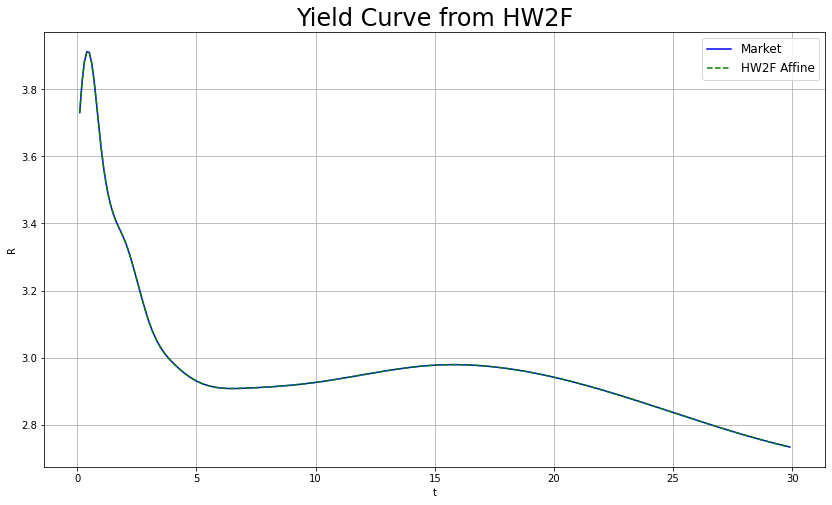

In [23]:
t = np.arange(0.1,30,0.1)
HW2F_ZCB_Prices = np.zeros_like(t)

for i in range(len(t)):
    HW2F_ZCB_Prices[i] = HW2F_ZCB(a,b,σ_1,σ_2,ρ,P0T,0,t[i],x_t,y_t)
    
    
fig = plt.figure(figsize=(14,8))
plt.grid()
plt.xlabel('t')
plt.ylabel('R')
plt.plot(t,zero_coupon_to_yield(t, P0T(t)),linestyle='-', color = 'b', label = 'Market')
plt.plot(t,zero_coupon_to_yield(t,HW2F_ZCB_Prices),linestyle='--', color = 'g', label = 'HW2F Affine')
plt.title('Yield Curve from HW2F',fontsize = 24)
plt.legend(fontsize = 'large');

## Generate yield curves at time t = 10

$$r(t) = x(t) + y(t) + \varphi(t)$$

Where

$$
\begin{align}
\begin{split}
   dx(t) &= -a\cdot x(t)\cdot dt + \sigma_1dW_1(t) \\
   dy(t) &= -b\cdot y(t)\cdot dt + \sigma_2dW_2(t) \\
 \varphi(t) &= f(0,t) +\frac{\sigma_1^2}{2a^2}(1-e^{-at})^2 + \frac{\sigma_2^2}{2b^2}(1-e^{-bt})^2 + \rho\frac{\sigma_1\sigma_2}{2ab}(1-e^{-at})(1-e^{-bt})
\end{split}
\end{align}
$$

0.0012


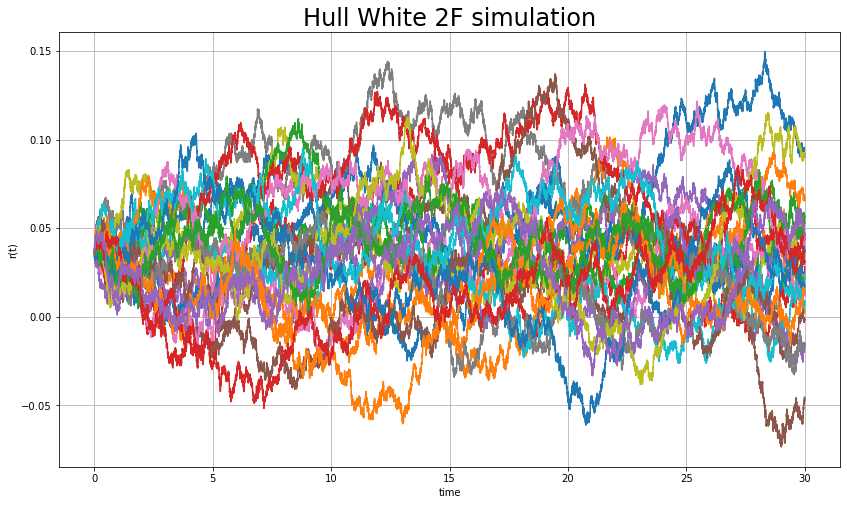

In [24]:
def GeneratePathsHW2FEuler(M,N,T,P0T, a,b, σ_1,σ_2,ρ):    
    ϕ = lambda t: f0T(t) + (σ_1**2.0)/(2.0*a**2.0)*(1.0-np.exp(-a*t))**2 \
                         + (σ_2**2.0)/(2.0*b**2.0)*(1.0-np.exp(-b*t))**2 \
                         + ρ*σ_1*σ_2/(a*b)*(1.0-np.exp(-a*t))*(1.0-np.exp(-b*t))
    
    Z1 = np.random.normal(0.0,1.0,[M,N])
    Z2 = np.random.normal(0.0,1.0,[M,N])
    Z2 = ρ * Z1 + np.sqrt(1.0-ρ**2)*Z2
    W1 = np.zeros([M, N+1])
    W2 = np.zeros([M, N+1])
    X = np.zeros([M, N+1])
    Y = np.zeros([M, N+1])
    R = np.zeros([M, N+1])
    R[:,0] = ϕ(0)
    t = np.zeros([N+1])
        
    dt = T / float(N)
    for i in range(0,N):    
        W1[:,i+1] = W1[:,i] + Z1[:,i]*np.sqrt(dt)
        W2[:,i+1] = W2[:,i] + Z2[:,i]*np.sqrt(dt)
        
        dWt_1 = W1[:,i+1] -  W1[:,i]
        dWt_2 = W2[:,i+1] -  W2[:,i]
        
        X[:,i+1] = X[:,i] - a*X[:,i] * dt + σ_1* dWt_1
        Y[:,i+1] = Y[:,i] - b*Y[:,i] * dt + σ_2* dWt_2
        t[i+1] = t[i] +dt

        R[:,i+1] = X[:,i+1] + Y[:,i+1] + ϕ(t[i+1])
    
    # Outputs
    paths = {"t":t,"R":R,"X":X,"Y":Y}
    print(dt)
    return paths



M = 1000 # Number of paths
N = 100*250 # Number of time steps
T = 30 # forwar time to start producing the curves

paths= GeneratePathsHW2FEuler(M,N,T,P0T, a,b, σ_1,σ_2,ρ)
x_t = paths["X"][:,-1]
y_t = paths["Y"][:,-1]
r = paths["R"]
t = paths["t"]


fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
plt.plot(t,r[0:25,:].T )
plt.grid()
plt.xlabel("time")
plt.ylabel("r(t)");
# plt.axvline(x=T_f, linestyle='--', color = 'black')
plt.title('Hull White 2F simulation', fontsize = 24);

